<a href="https://colab.research.google.com/github/DahianaRH/customer-churn-prediction-ml/blob/main/churn_problem_description.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción del abandono de clientes en telecomunicaciones

## Descripción del problema y análisis exploratorio de datos Dataset: Telco Customer Churn

## 1. Contexto del problema
En la industria de telecomunicaciones, la pérdida de clientes (customer churn) representa un problema crítico debido al impacto en los ingresos. Identificar de manera temprana a los clientes con alta probabilidad de abandono permite diseñar estrategias de retención más efectivas.
Este problema puede abordarse mediante técnicas de aprendizaje automático, modelando la probabilidad de abandono a partir de variables demográficas, servicios contraatados y comportamientos de facturación de servicios.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
url = "https://raw.githubusercontent.com/DahianaRH/customer-churn-prediction-ml/main/data/telco_customer_churn.csv"
df = pd.read_csv(url)

### Exploración General

In [41]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


La muestra del dataset evidencia que se cuenta con variables demográficas, de servicios contratados y de facturación, las cuales serán utilizadas para predecir la variable objetivo Churn.

In [42]:
df.shape

(7043, 21)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


El dataset contiene 7043 registros y 21 variables, predominando las variables categóricas. No se observan valores nulos inicialmente, aunque TotalCharges requiere conversión a tipo numérico para su correcto análisis.

## 2. Descripción del dataset
El dataset contiene información de aproximadamente 7000 clientes y 21 variables, incluyendo datos demográficos, servicios contratados y variables de facturación.

La variable objetivo es **Churn**, que nos indica si el cliente abandonó el servicio (Yes/No).

### Tipos de variables

In [44]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


La mayoría de las variables son categóricas y deberán ser codificadas. Además, TotalCharges requiere conversión a tipo numérico para su correcto análisis.

### Análisis de valores faltantes

In [54]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [53]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [47]:
df = df.dropna(subset=['TotalCharges']).copy()

Se observa que la mayoría de las variables no presentan valores faltantes. Sin embargo, la variable TotalCharges contiene 11 valores nulos, los cuales representan una proporción muy pequeña del dataset. Por esta razón se decide eliminar estas filas para evitar inconsistencias en el análisis.

In [52]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Luego del tratamiento, se verifica que el dataset no presenta valores faltantes en ninguna variable, por lo que se encuentra listo para las etapas posteriores de análisis y modelado.

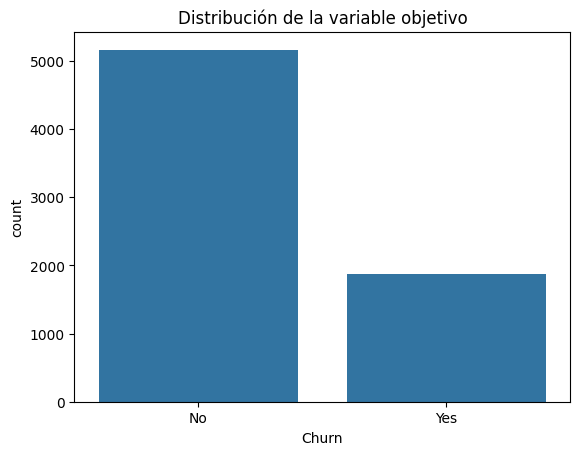

In [48]:
sns.countplot(x='Churn', data=df)
plt.title("Distribución de la variable objetivo")
plt.show()

Se observa un desbalance de clases, lo cual debemos tener en consideración en etapas posteriores mediante técnicas de balanceo o métricas adecuadas, como las vistas en clases.

In [49]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


Las variables numéricas muestran una alta variabilidad. tenure indica que existen tanto clientes nuevos como antiguos.
MonthlyCharges presenta distintos niveles de cobro según el tipo de servicio.
TotalCharges varía ampliamente, lo cual es consistente con su relación con el tiempo de permanencia y el costo mensual.
Además, se observan algunos valores faltantes en esta última variable.

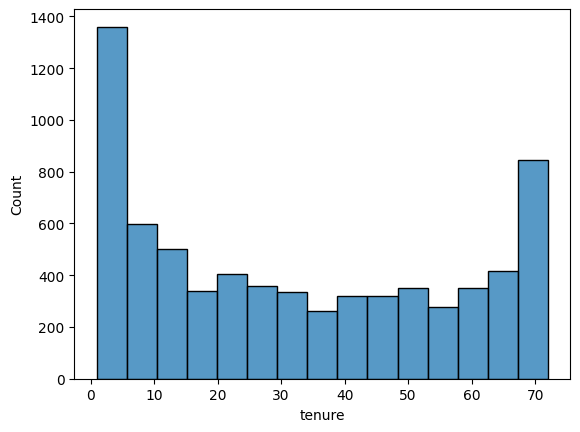

In [50]:
sns.histplot(df['tenure'])
plt.show()

La variable tenure, que representa el tiempo de permanencia del cliente, presenta una distribución no uniforme. Se observa una alta concentración de clientes en los primeros meses, así como un segundo grupo importante de clientes con larga permanencia (mayor a 60 meses). Esto sugiere la existencia de dos perfiles:
1.   Clientes nuevos con mayor probabilidad de abandono
2.   Clientes consolidados con menor riesgo.

Esto nos indica que esta variable tiene un alto poder predictivo para el problema de churn.

In [51]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

La variable objetivo Churn fue codificada en formato binario, asignando el valor 1 a los clientes que abandonan el servicio (Yes) y 0 a los que permanecen (No), con el fin de ser utilizada en modelos de clasificación supervisada.

## 3. Paradigma de aprendizaje

El problema se aborda como una tarea de **clasificación supervisada**, ya que se dispone de etiquetas (Churn) y el objetivo es predecir si un cliente abandonará el servicio.

Este enfoque es adecuado debido a la naturaleza del problema y la disponibilidad de datos históricos etiquetados.